<a href="https://colab.research.google.com/github/ThAlvesM/Kmean_2026-1/blob/Test%2FNovo_dataset/Kmean_2026-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

----------------------------------------
# Seção 1: Introdução
----------------------------------------

## Contextualização

 O K-means, por ser um algoritmo de clustering, é extremamente útil para identificação de padrões. Nesse sentido, focaremos no seguinte problema de negócio:

Uma determinada loja possui dados sobre seus clientes e pretende desenvolver um trabalho de análise de dados para compreender melhor o comportamento e características de cada perfil de cliente. A loja pretende promover promoções, descontos e ações publicitárias para fortalecer as vendas de produtos específicos, identificar quais produtos e setores da loja são mais frequentados por determinados perfis de clientes e criar estratégias de mercado para engajar grupos de clientes específicos. 

## Objetivo

 Buscamos responder a seguinte pergunta: *Quais são os principais perfis/segmentos de clientes da loja com base em informações gerais sobre renda, ocupação, escolaridade, etc?*

Além disso, pretendemos, a partir da análise dos dados e dos resultados do modelo verificar a validade de hipóteses prévias sobre a correlação das diferentes variáveis. Esperamos que colunas como Renda e o tipo de emprego do cliente, Idade e Educação, Renda e Educação sejam altamente correlacionadas, por exemplo.



## Descrição dos Dados

 O Dataset escolhido é o "Segmentation data", oriundo do [Kaggle](https://www.kaggle.com/datasets/dev0914sharma/customer-clustering?select=segmentation+data.csv). O dono da loja obtém informações sobre os clientes por meio de cartões de fidelidade. Em relação ao significado de cada coluna do Dataset, o seguinte dicionário traz uma boa descrição:

* Customer ID (int)
    - ID único que identifica cada cliente da loja

* Sex (int) - Qualitativa, codificada
    - Indica o sexo do cliente.
    >  0: Homem,  1: Mulher 

* Matiral Status (int) - Qualitativa, codificada
    - Estado civil do cliente
    > 0: solteiro, 1: não solteiro (casado/divorciado/separado/viuvo)

* Age (int) - Quantitativa
    - Idade do cliente

* Education (int) - Qualitativa, codificada
    - Escolaridade do cliente
    > 0: desconhecido, 1: Ensino médio, 2: Graduação, 3: Pós-Graduação 

* Income (int) - Quantitativa
     - Renda anual do cliente em dólares

* Occupation (int) - Qualitativa, codificada
   - Categoria da ocupação profissional do cliente
   > 0: desempregado, 1: empregado regular, 2: empregado em gestão / funcionário autônomo / funcionário altamente qualificado 

* Settlement Size (int) - Qualitativa, codificada
     - Tamanho da cidade na qual o cliente mora
     >0: cidade pequena, 1: cidade de tamanho média, 2: cidade grande



-----------------------------------------------
#Seção 2: Análise Exploratória de Dados (EDA)
-----------------------------------------------
● 2.1. Carregamento e Limpeza dos Dados: Importe os dados e mostre os primeiros
passos de verificação (ex: .info(), .describe(), .isnull() .sum()). Descreva como tratou
dados faltantes, duplicados ou inconsistentes.

In [16]:
install.packages("GGally")
library(GGally)
library(ggplot2)
library(tidyr)
library(dplyr)


Installing package into ‘/home/arthur/R/x86_64-redhat-linux-gnu-library/4.5’
(as ‘lib’ is unspecified)



In [17]:
install.packages("fastDummies")
library(fastDummies)

Installing package into ‘/home/arthur/R/x86_64-redhat-linux-gnu-library/4.5’
(as ‘lib’ is unspecified)



In [18]:
dataset <- read.csv ("segmentation_data.csv", header = TRUE)
#Fazer alguma verificação aqui no meio
print("Dataset Instalado com Sucesso")

[1] "Dataset Instalado com Sucesso"


In [19]:
dataset_analise <- dataset
dataset_analise$Sex <- factor(
  dataset_analise$Sex, 
  levels = c(0, 1),
  labels = c("Homem", "Mulher") 
)
dataset_analise$Sex<- as.character(dataset_analise$Sex)
dataset_analise$Marital.status <- factor(
  dataset_analise$Marital.status, 
  levels = c(0, 1),
  labels = c("Solteiro", "Não solteiro") 
)
dataset_analise$Marital.status<- as.character(dataset_analise$Marital.status)
#Convertendo a coluna Education
dataset_analise$Education <- factor(
  dataset_analise$Education, 
  levels = c(0, 1, 2, 3),
  labels = c("Desconhecido", "Ensino médio", "Graduação", "Pós-Graduação")
)
dataset_analise$Education<- as.character(dataset_analise$Education)
#Convertendo a coluna Occupation
dataset_analise$Occupation <- factor(
  dataset_analise$Occupation, 
  levels = c(0, 1, 2),
  labels = c("Desempregado", "Empregado regular", "Funcionário altamente qualificado")
)
dataset_analise$Occupation<- as.character(dataset_analise$Occupation)
#Convertendo a coluna Settlement.Size
dataset_analise$Settlement.size <- factor(
  dataset_analise$Settlement.size, 
  levels = c(0, 1, 2),
  labels = c("Cidade pequena", "Cidade de tamanho média", "Cidade grande")
)
dataset_analise$Settlement.size<- as.character(dataset_analise$Settlement.size)


In [20]:
# Exibindo a quantidade de linhas e colunas do dataset, respectivamente
dim(dataset_analise)

[1] 2000    8

In [21]:
# Primeiras 6 linhas do dataset
head(dataset_analise)

,ID,Sex,Marital.status,Age,Education,Income,Occupation,Settlement.size
,<int>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>
1,100000001,Homem,Solteiro,67,Graduação,124670,Empregado regular,Cidade grande
2,100000002,Mulher,Não solteiro,22,Ensino médio,150773,Empregado regular,Cidade grande
3,100000003,Homem,Solteiro,49,Ensino médio,89210,Desempregado,Cidade pequena
4,100000004,Homem,Solteiro,45,Ensino médio,171565,Empregado regular,Cidade de tamanho média
5,100000005,Homem,Solteiro,53,Ensino médio,149031,Empregado regular,Cidade de tamanho média
6,100000006,Homem,Solteiro,35,Ensino médio,144848,Desempregado,Cidade pequena


In [22]:
info_colun_num <- function(c){
  cat("Tipo:", typeof(c), "| NAs:", sum(is.na(c) | c == ""), "| Únicos:", n_distinct(c), "\n")
  cat(paste("5 primeiros elementos:",
  c[1], " - ", c[2], " - ",c[3], " - ",c[4], " - ",c[5], "\n"))

  if (is.numeric(c)) {
    cat(paste("Mínimo:", round(min(c), 2), "\t"))
    cat(paste("1ºQuart:", round(quantile(c, probs = 0.25), 2), "\t"))
    cat(paste("Média:", round(mean(c),2), "\t"))
    cat(paste("3ºQuart:", round(quantile(c, probs = 0.75), 2), "\t"))
    cat(paste("Máximo:", round(max(c), 2), "\n"))
    cat(paste("Desvio Padrão:", round(sd(c), 2),"\t"))
    cat(paste("Mediana", round(median(c), 2),"\n"))

  } else {
      cat(paste("Máximo caracteres:", max(nchar(c)), "\t"))
      cat(paste("Mínimo caracteres:", min(nchar(c)), "\n"))

      tab_abs <- table(c)
      names(dimnames(tab_abs)) <- "Frequncia Absoluta"
      print(tab_abs)


      tab_rel <- prop.table(table(c)) * 100
      names(dimnames(tab_rel)) <- "Frequencia Relativa"
      print(tab_rel)

  }
}

In [23]:
#Coluna Sexo
cat("Sex\n")
info_colun_num(dataset_analise$Sex)
cat("-------------------------------------------------\n")
#Coluna estado civil
cat("Matiral status\n")
info_colun_num(dataset_analise$Marital.status)
cat("-------------------------------------------------\n")
#Coluna Idade
cat("Age\n")
info_colun_num(dataset_analise$Age)
cat("-------------------------------------------------\n")
#Coluna Salario Anual
cat("Education level\n")
info_colun_num(dataset_analise$Education)
cat("-------------------------------------------------\n")
#Coluna Score de Gasto
cat("Income\n")
info_colun_num(dataset_analise$Income)
cat("-------------------------------------------------\n")
#Coluna Profissao
cat("Occupation type\n")
info_colun_num(dataset_analise$Occupation)
cat("-------------------------------------------------\n")
#Coluna Experiencia de Trabalho
cat("Settlement size\n")
info_colun_num(dataset_analise$Settlement.size)
cat("-------------------------------------------------\n")
#Coluna Familiares
# cat("Family Size\n")
# info_colun_num(dataset_analise$Family.Size)
# cat("-------------------------------------------------\n")

Sex
Tipo: character | NAs: 0 | Únicos: 2 
5 primeiros elementos: Homem  -  Mulher  -  Homem  -  Homem  -  Homem 
Máximo caracteres: 6 	Mínimo caracteres: 5 
Frequncia Absoluta
 Homem Mulher 
  1086    914 
Frequencia Relativa
 Homem Mulher 
  54.3   45.7 
-------------------------------------------------
Matiral status
Tipo: character | NAs: 0 | Únicos: 2 
5 primeiros elementos: Solteiro  -  Não solteiro  -  Solteiro  -  Solteiro  -  Solteiro 
Máximo caracteres: 12 	Mínimo caracteres: 8 
Frequncia Absoluta
Não solteiro     Solteiro 
         993         1007 
Frequencia Relativa
Não solteiro     Solteiro 
       49.65        50.35 
-------------------------------------------------
Age
Tipo: integer | NAs: 0 | Únicos: 58 
5 primeiros elementos: 67  -  22  -  49  -  45  -  53 
Mínimo: 18 	1ºQuart: 27 	Média: 35.91 	3ºQuart: 42 	Máximo: 76 
Desvio Padrão: 11.72 	Mediana 33 
-------------------------------------------------
Education level
Tipo: character | NAs: 0 | Únicos: 4 
5 primeiros 

In [24]:
cat("Total de Ids duplicados no dataset:", sum(duplicated(dataset[1])), "\n")
cat("Total de clientes duplicados no dataset:", sum(duplicated(dataset[2:8]))) # considerando todas as colunas menos o ID

Total de Ids duplicados no dataset: 0 
Total de clientes duplicados no dataset: 0

In [25]:
check_NA <- function(c) {
    cat("NAs:", sum(is.na(c) | c == ""))
}

cnt = 1
for (col in dataset) {
    cat(colnames(dataset)[cnt], "- ")
    check_NA(col)
    cat("\n")
    cnt <- cnt + 1
}


ID - NAs: 0
Sex - NAs: 0
Marital.status - NAs: 0
Age - NAs: 0
Education - NAs: 0
Income - NAs: 0
Occupation - NAs: 0
Settlement.size - NAs: 0


## Análise Univariada
● 2.2. Análise Univariada: Explore as variáveis individualmente. Use gráficos
(histogramas, boxplots, etc) e métricas para entender a distribuição e as características
de cada variável relevante. Comente suas observações.

In [26]:
dataset_sem_id <- dataset[2:8] #Removendo a coluna de IDs por conveniência. A variável ID não teria nenhum impacto real nas análises

### Sex

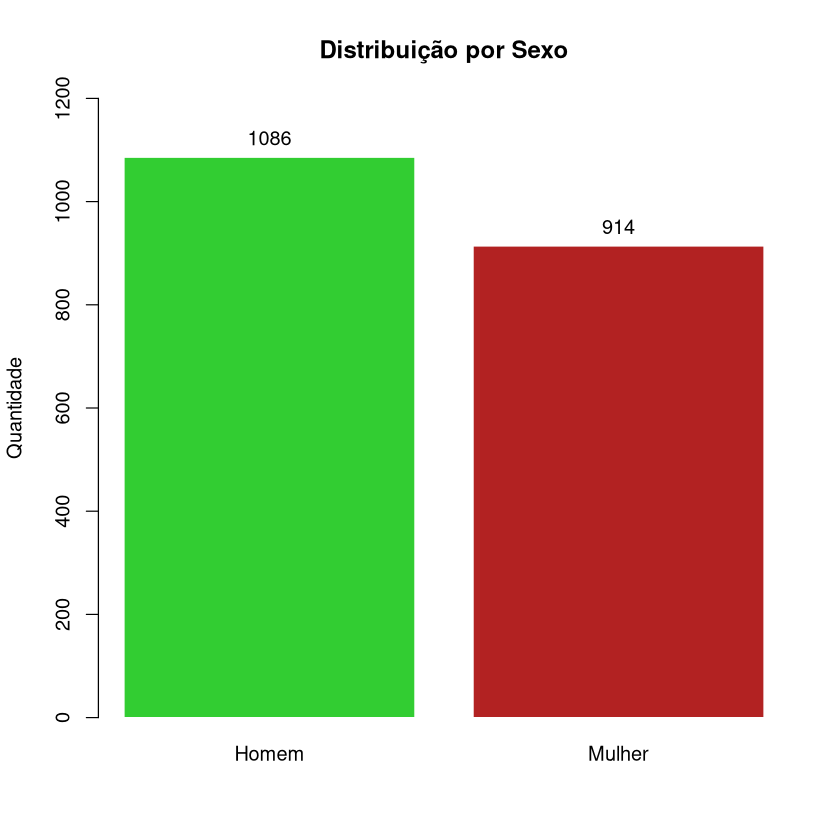

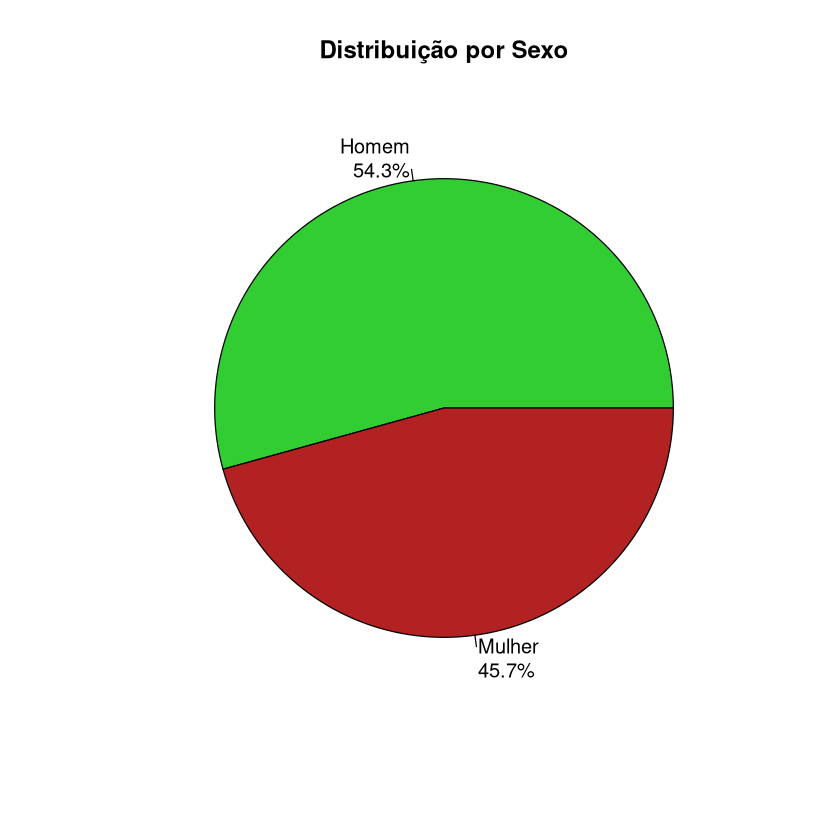

In [27]:
par(bg = "white")

Sex_var <- table(dataset_sem_id$Sex)

bp <- barplot(
    Sex_var,
    names.arg = c("Homem", "Mulher"),
    main = "Distribuição por Sexo",
    ylab = "Quantidade",
    col = c("limegreen", "firebrick"),
    border = "white",
    ylim = c(0, 1200)
)
contagem <- table(dataset_sem_id$Sex)

text(bp, contagem, labels = Sex_var, pos = 3)


pizza <- pie(
    Sex_var,
    main = "Distribuição por Sexo",
    labels = paste0(
        c("Homem", "Mulher"),
        "\n",
        round(contagem / sum(contagem) * 100, 1),
        "%"
    ),
    col = c("limegreen", "firebrick"),
    
)

No nosso dataset, percebe-se que existe uma maior represetação de homens do que mulheres, embora pequena.

### Marital Status

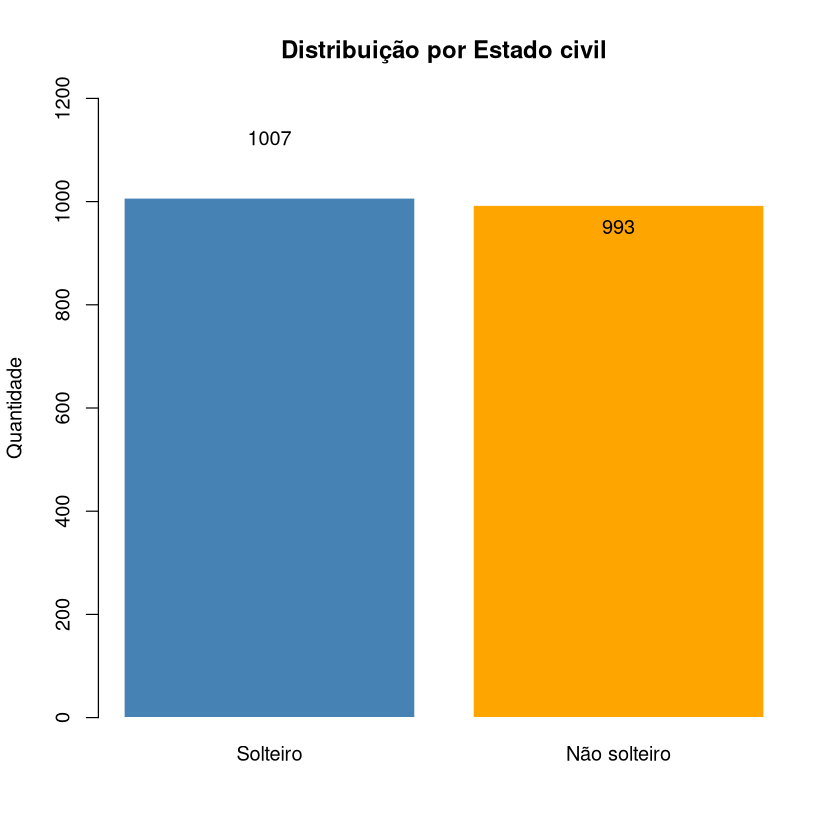

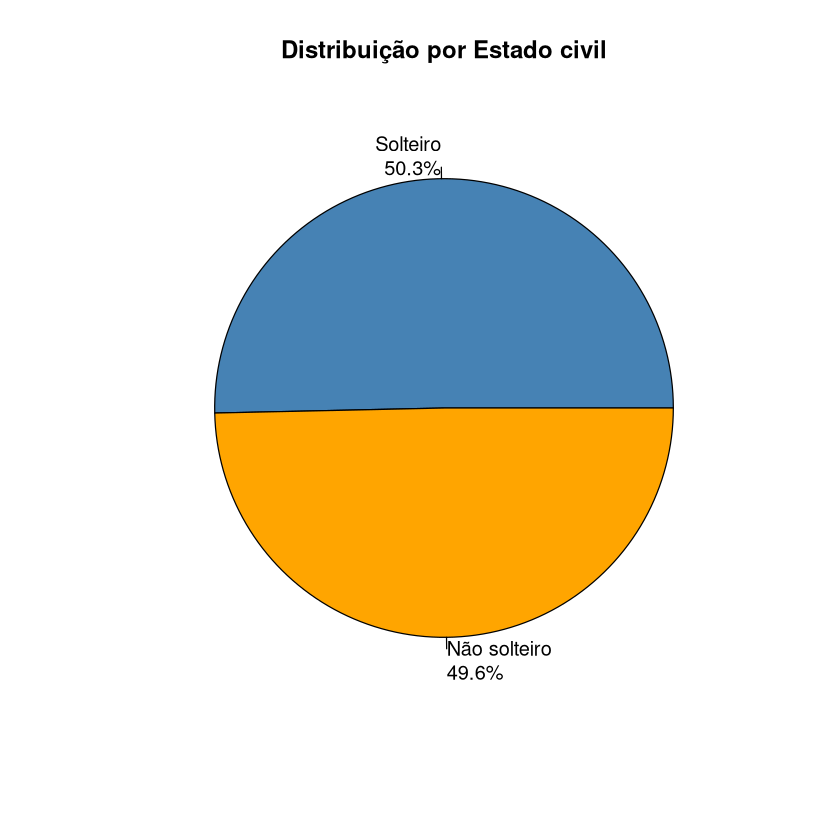

In [28]:
par(bg = "white")

Marital_var <- table(dataset_sem_id$Marital.status)

bp <- barplot(
    Marital_var,
    names.arg = c("Solteiro", "Não solteiro"),
    main = "Distribuição por Estado civil",
    ylab = "Quantidade",
    col = c("steelblue", "orange"),
    border = "white",
    ylim = c(0, 1200)
)

text(bp, contagem, labels = Marital_var, pos = 3)

contagem <- table(dataset_sem_id$Marital.status)

pizza <- pie(
    Marital_var,
    main = "Distribuição por Estado civil",
    labels = paste0(
        c("Solteiro", "Não solteiro"),
        "\n",
        round(contagem / sum(contagem) * 100, 1),
        "%"
    ),
    col = c("steelblue", "orange"),
    
)

Neste dataset, a disparidade entre as duas categorias de estado civil é baixa.

### Age

Quantidade de outliers: 57
Proporção de clientes com idade entre 20 e 40 anos: 0.7135

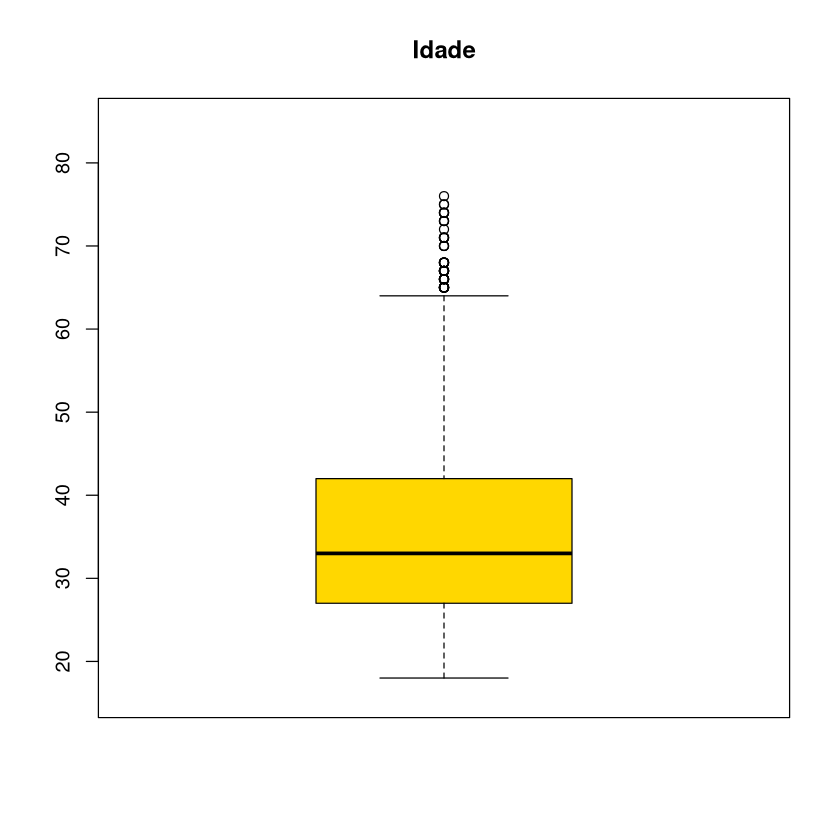

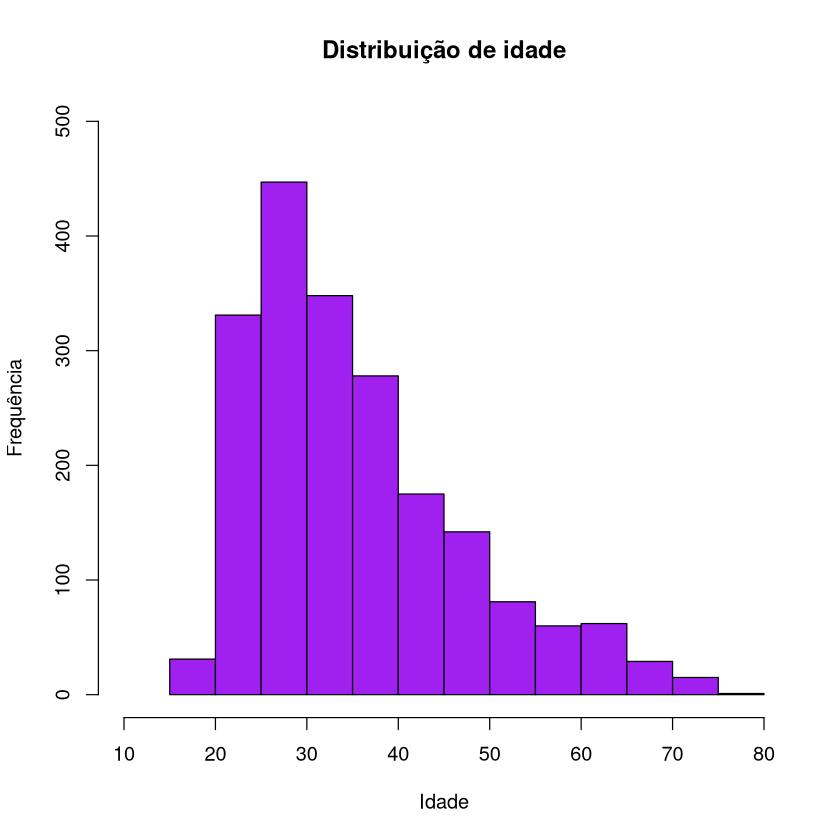

In [29]:
par(bg = "white")

Age_var <- dataset_sem_id$Age

bp <- boxplot(
    Age_var,
    main = "Idade",
    col = "gold",
    ylim = c(16, 85)
)

check_sixtyfive <- function(c) {
    cat("Quantidade de outliers:", sum(c >= 65))
}

check_sixtyfive(Age_var)
cat("\n")

check_20to40 <- function(c) {
    cat("Proporção de clientes com idade entre 20 e 40 anos:", sum(c <= 40 & c >= 20)/2000)
}

check_20to40(Age_var)

ht <- hist(
    Age_var,
    main = "Distribuição de idade",
    xlab = "Idade",
    ylab = "Frequência",
    ylim = c(0, 500),
    xlim = c(10,80),
    col = "purple"
)

A partir da análise do gráfico BoxPlot, percebemos que existem 57 *outliers*. Para definir isso, tomamos conta da fórmula de limite superior do BoxPlot, definida por:

**Limite superior = 3 Quartil + ((3 Quartil - 1 Quartil) * 1.5)**

Calculando, obtemos o valor do Limite superior como 64.5, isto é, idades acima de 65 anos são consideradas *outliers*.

A partir da análise do histograma, percebe-se que a distribuição de idade na amostra NÃO segue um modelo normal.

Outras observações seriam: Existe uma concentração de clientes com idades entre 20 e 40, os quais representam aproximadamente 71% do total de clientes; 

### Education

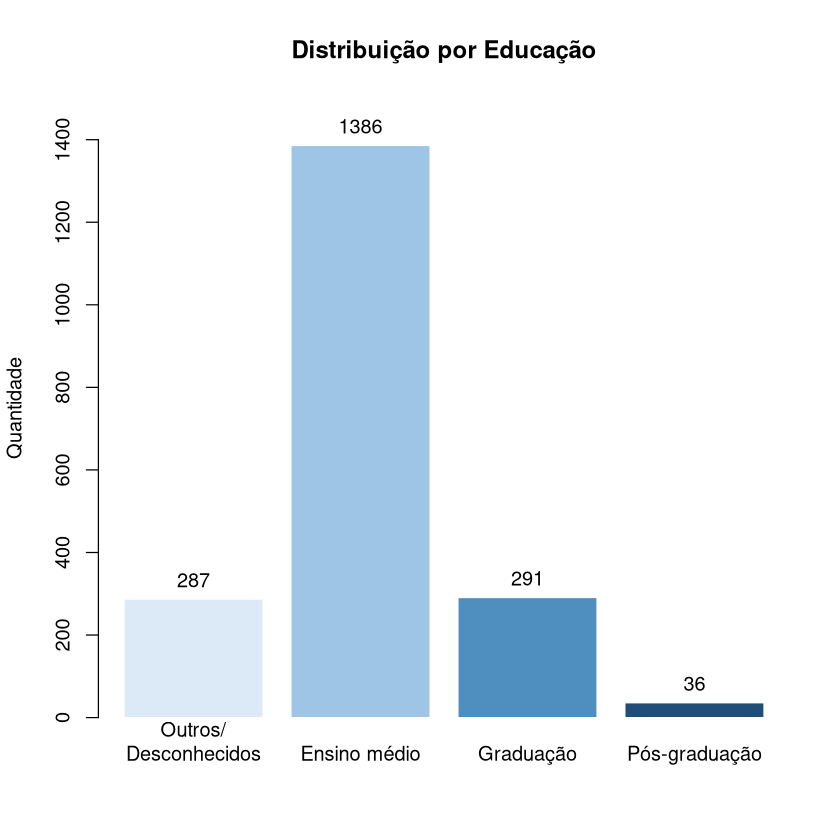

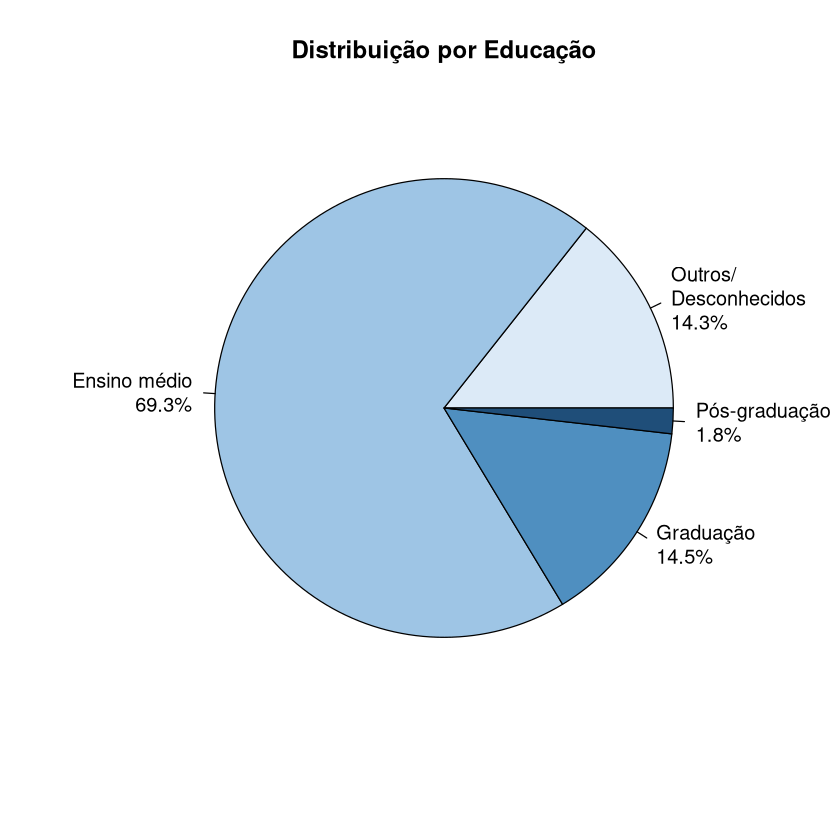

In [48]:
par(bg = "white")

Education_var <- table(dataset_sem_id$Education)

bp <- barplot(
    Education_var,
    names.arg = c("Outros/\nDesconhecidos", "Ensino médio", "Graduação", "Pós-graduação"),
    main = "Distribuição por Educação",
    ylab = "Quantidade",
    border = "white",
    ylim = c(0, 1500),
    col = c("#DCEAF7", "#9EC5E5", "#4F8FC0", "#1F4E79")
)

text(bp, contagem, labels = Education_var, pos = 3)

contagem <- table(dataset_sem_id$Education)

pizza <- pie(
    Education_var,
    main = "Distribuição por Educação",
    labels = paste0(
        c("Outros/\nDesconhecidos", "Ensino médio", "Graduação", "Pós-graduação"),
        "\n",
        round(contagem / sum(contagem) * 100, 1),
        "%"
    ),
    col = c("#DCEAF7", "#9EC5E5", "#4F8FC0", "#1F4E79")
    
)

A partir da análise dos gráficos acima, percebe-se que a amostra é composta, majoritariamente, por clientes não graduados com ensino médio completo, representando 69,3% do total. Além disso, uma quantia considerável de clientes possue escolaridade que foge a alguma das três classificações em questão (ensino médio, graduação e pós-graduação) ou possue escolaridade desconhecida.

### Income

Quantidade de outliers em relação ao limite superior: 81


Quantidade de outliers em relação ao limite inferior: 2

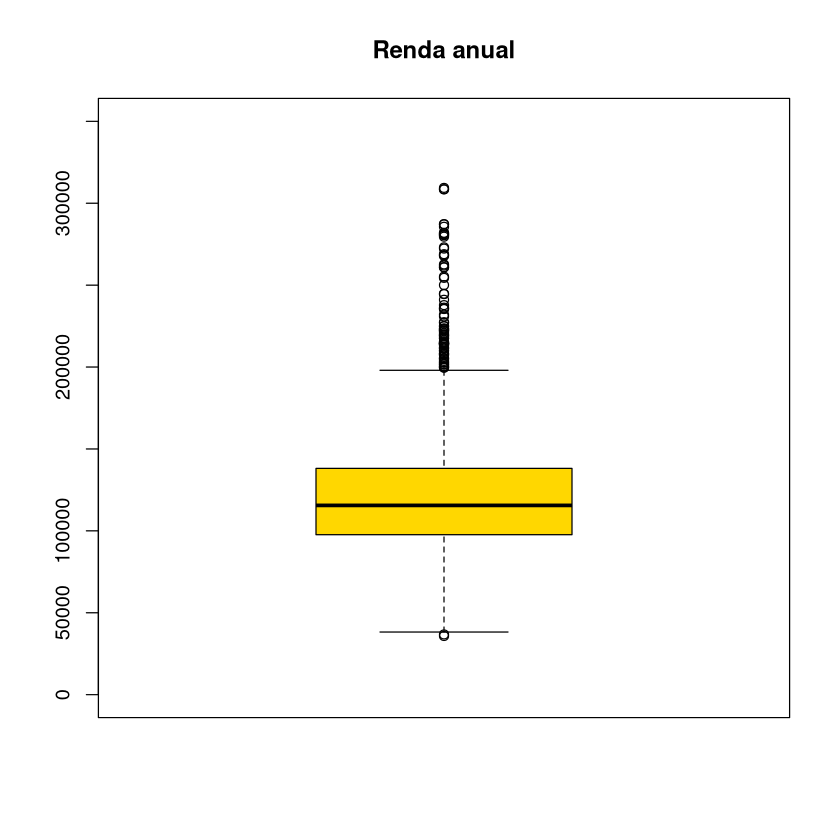

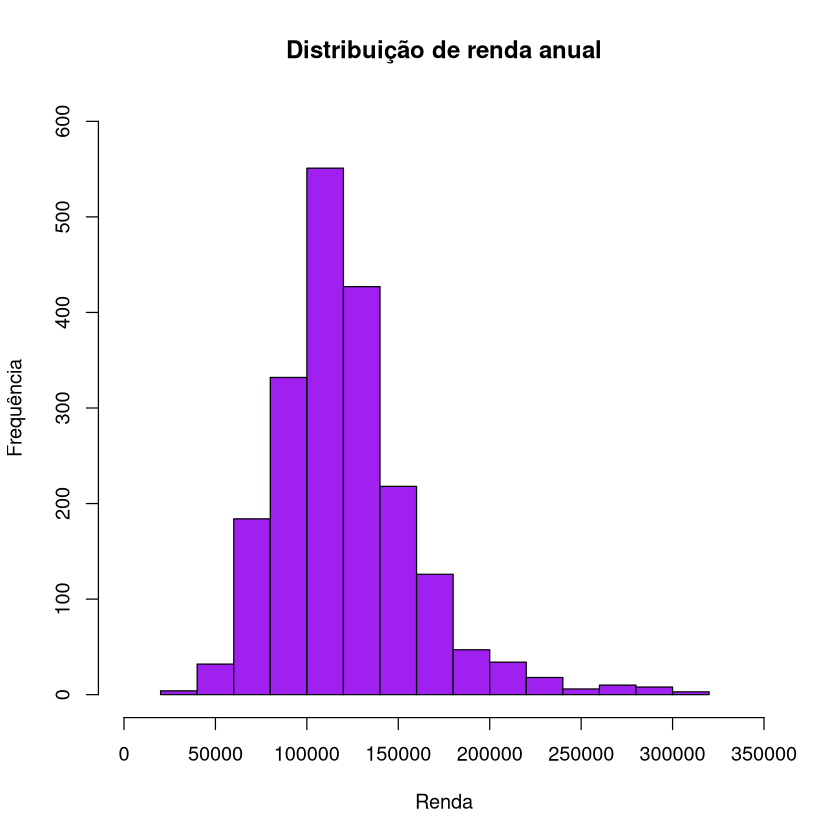

In [31]:
par(bg = "white")

Income_var <- dataset_sem_id$Income

bp <- boxplot(
    Income_var,
    main = "Renda anual",
    col = "gold",
    ylim = c(0, 350000)
)

check_upper_lim <- function(c) {
    cat("Quantidade de outliers em relação ao limite superior:", sum(c > 198685.75))
}

check_lower_lim <- function(c) {
    cat("Quantidade de outliers em relação ao limite inferior:", sum(c < 37049.75))
}

check_upper_lim(Income_var)
cat("\n")
check_lower_lim(Income_var)

ht <- hist(
    Income_var,
    main = "Distribuição de renda anual",
    xlab = "Renda",
    ylab = "Frequência",
    col = "purple",
    xlim = c(0, 350000),
    ylim = c(0, 600)
)

A partir da análise do gráfico BoxPlot, percebemos que existem 83 *outliers* totais, sendo 81 em relação ao limite superior (acima de 198685.75) e 2 em relação ao limite inferior (abaixo de 37049.75). Para definir isso, tomamos conta das fórmulas de limite superior e de limite inferior do BoxPlot, definidas por:

**Limite superior = 3 Quartil + ((3 Quartil - 1 Quartil) * 1.5)**

**Limite inferior = 1 Quartil - ((3 Quartil - 1 Quartil) * 1.5)**

Calculando, obtemos o valor do Limite superior como 198685.75, isto é, valores acima disso são considerados *outliers*. Já o limite inferior resulta em 37049.75 e valores abaixo disso também são *outliers*.

A partir da análise do histograma, percebe-se que a distribuição de renda anual na amostra NÃO segue um modelo normal. 

### Occupation

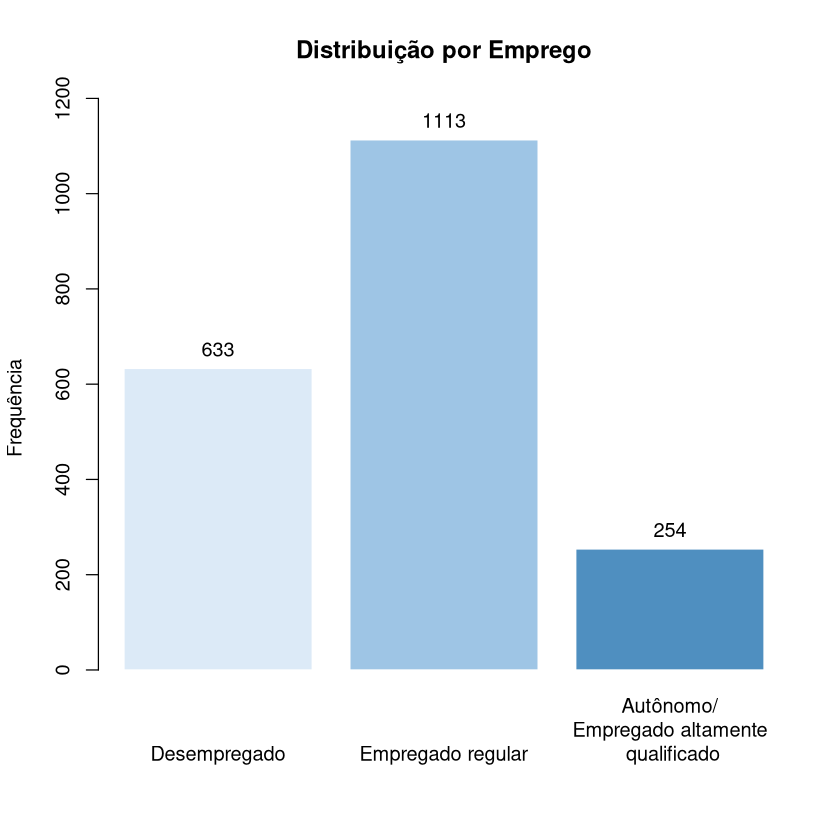

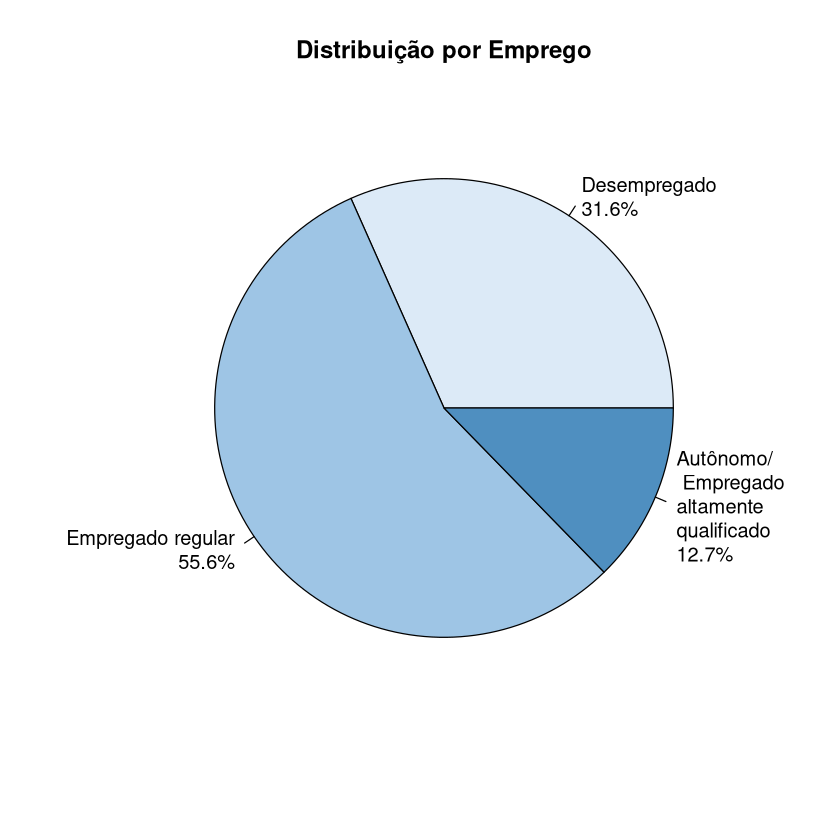

In [32]:
par(bg = "white")

Occupation_var <- table(dataset_sem_id$Occupation)

bp <- barplot(
    Occupation_var,
    names.arg = c("Desempregado", "Empregado regular", "\n Autônomo/ \n Empregado altamente \n qualificado"),
    main = "Distribuição por Emprego",
    ylab = "Frequência",
    border = "white",
    ylim = c(-100, 1200),
    col = c("#DCEAF7", "#9EC5E5", "#4F8FC0")
)
contagem <- table(dataset_sem_id$Occupation)

text(bp, contagem, labels = Occupation_var, pos = 3)


pizza <- pie(
    Occupation_var,
    main = "Distribuição por Emprego",
    labels = paste0(
        c("Desempregado", "Empregado regular", "Autônomo/ \n Empregado \naltamente \nqualificado"),
        "\n",
        round(contagem / sum(contagem) * 100, 1),
        "%"
    ),
    col = c("#DCEAF7", "#9EC5E5", "#4F8FC0")

)

A partir da análise dos gráficos de setor e de barras, percebe-se que a amostra possui uma grande quantidade de clientes em empregos regulares (55.6%) e, simultaneamente, possui um número considerável de clientes desempregados, somando quase um terço do total de clientes (31.6%).

### Settlement size

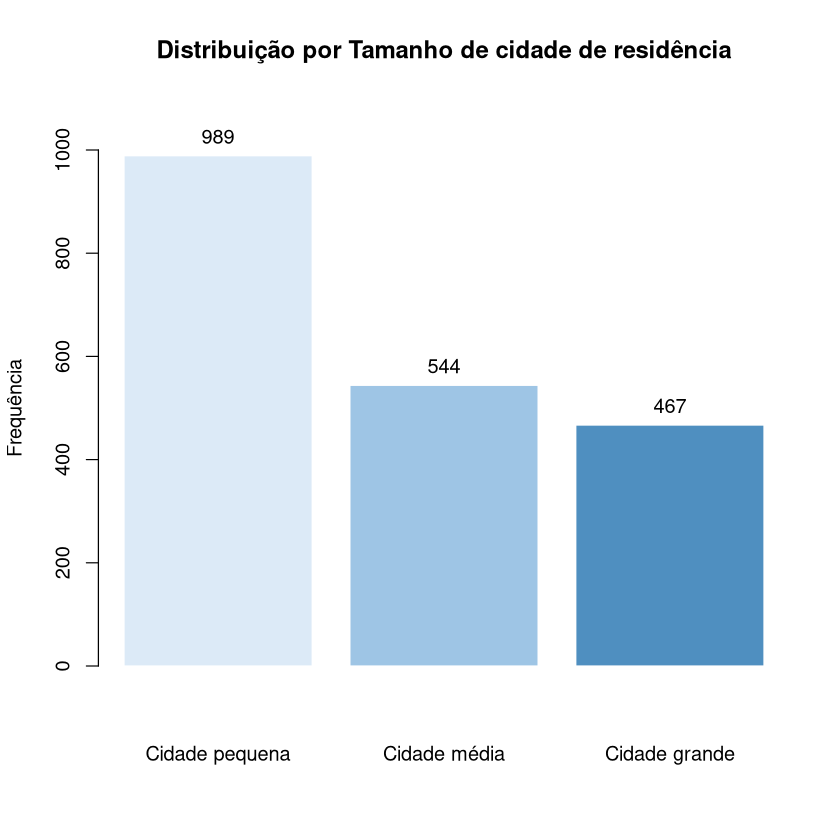

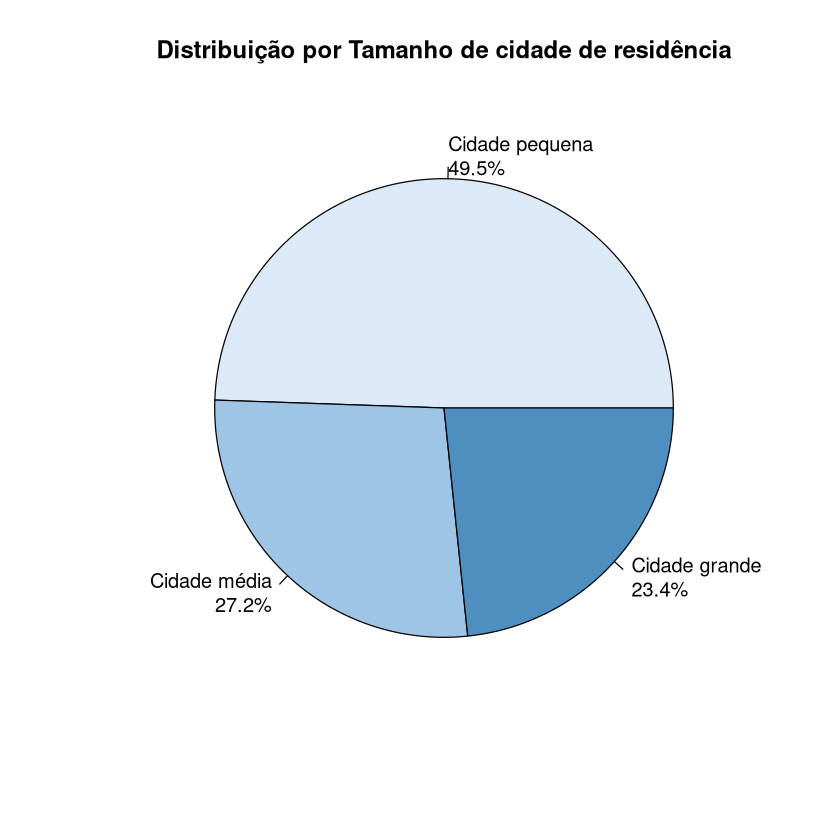

In [33]:
par(bg = "white")

Settlement_var <- table(dataset_sem_id$Settlement.size)

bp <- barplot(
    Settlement_var,
    names.arg = c("Cidade pequena", "Cidade média", "Cidade grande"),
    main = "Distribuição por Tamanho de cidade de residência",
    ylab = "Frequência",
    border = "white",
    ylim = c(-100, 1100),
    col = c("#DCEAF7", "#9EC5E5", "#4F8FC0")
)
contagem <- table(dataset_sem_id$Settlement.size)

text(bp, contagem, labels = Settlement_var, pos = 3)


pizza <- pie(
    Settlement_var,
    main = "Distribuição por Tamanho de cidade de residência",
    labels = paste0(
        c("Cidade pequena", "Cidade média", "Cidade grande"),
        "\n",
        round(contagem / sum(contagem) * 100, 1),
        "%"
    ),
    col = c("#DCEAF7", "#9EC5E5", "#4F8FC0")

)

Ao analisar os gráficos acima, é possível perceber que aproximadamente metade dos clientes da base de dados são residentes de cidades pequenas (49.5%). A outra metade dos clientes é dividida quase igualmente entre cidades médias (27.2%) e cidades grandes (23.4%).

# Análise Bivariada

● 2.3. Análise Bivariada e Multivariada: Investigue a relação entre as variáveis. Use
gráficos (scatter plots, heatmaps de correlação) e tabelas para identificar padrões,
tendências e correlações.

### Matriz de correlação e Heatmap

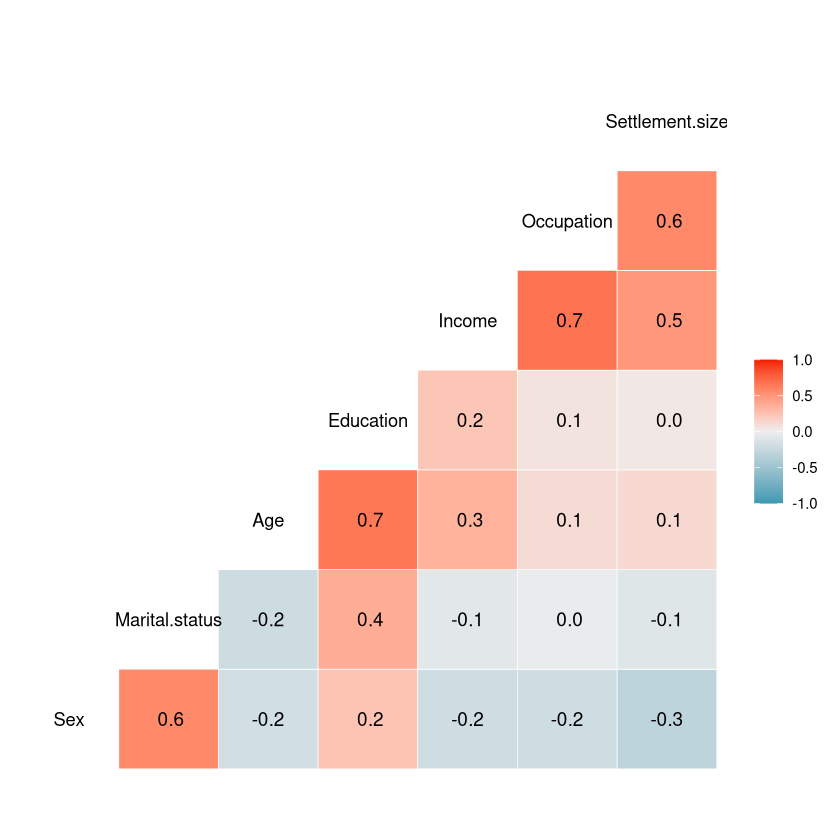

In [34]:
dataset_numerico <- dataset_sem_id[, sapply(dataset_sem_id, is.numeric)]
ggcorr(dataset_numerico, label=T)

A partir da análise do Heatmap de correlação, é possível perceber que existem múltiplas colunas que são consideravelmente correlacionadas:
* Sexo e Estado civil (taxa de correlação: 0.6)
* Idade e Educação (taxa de correlação: 0.7)
* Renda e Emprego (taxa de correlação: 0.7)
* Tamanho da cidade de residência e Emmprego (taxa de correlação: 0.6)
* Tamanho da cidade de residência e Renda (taxa de correlação: 0.5)

Além disso, existem colunas que não possuem nenhuma correlação:
* Educação e Tamanho da cidade de residência (taxa de correlação: 0)
* Estado civil e Emprego (taxa de correlação: 0)

As variáveis Renda e Idade possuem uma leve correlação (0.3), como mostra o Scatter plot abaixo.

`geom_smooth()` using formula = 'y ~ x'


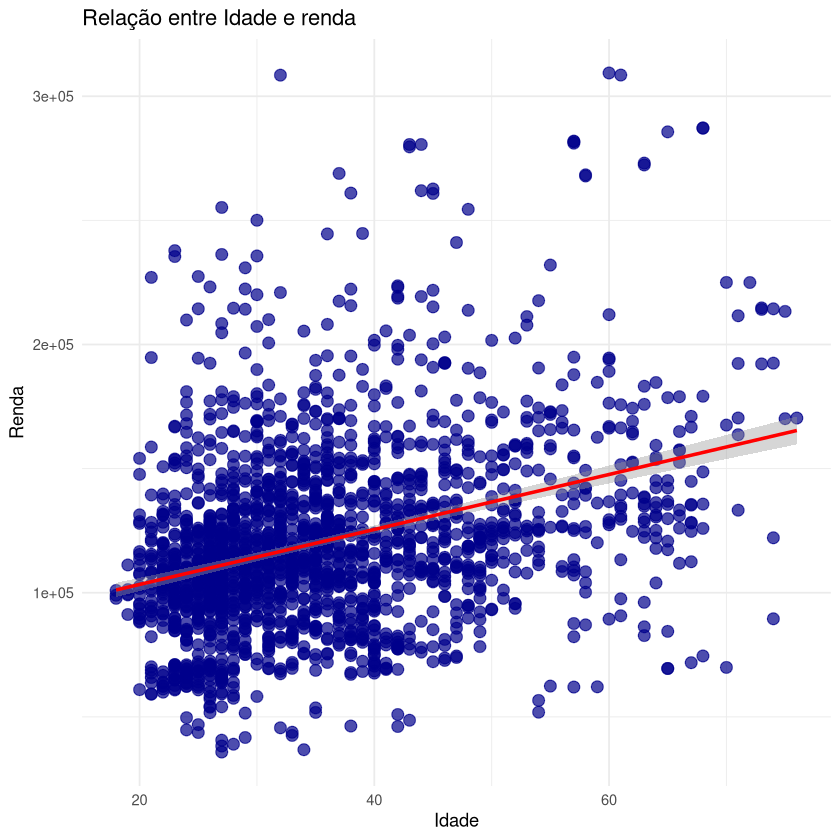

In [35]:
ggplot(dataset_sem_id, aes(x = Age, y = Income)) +
  geom_point(color = "darkblue", size = 3, alpha = 0.7) + 
  geom_smooth(method = "lm", color = "red", se = TRUE) +  
  theme_minimal() +                                       
  labs(title = "Relação entre Idade e renda",
       x = "Idade",
       y = "Renda")

As colunas Renda e Emprego possuem alta correlação (0.7).

`geom_smooth()` using formula = 'y ~ x'


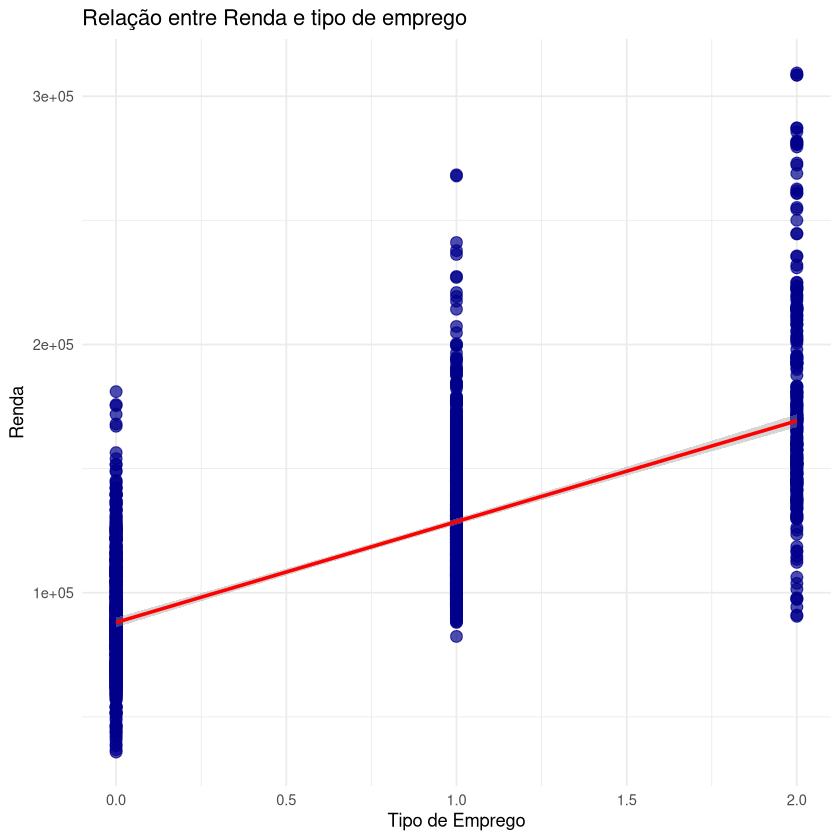

In [36]:
ggplot(dataset_sem_id, aes(x = Occupation, y = Income)) +
  geom_point(color = "darkblue", size = 3, alpha = 0.7) + 
  geom_smooth(method = "lm", color = "red", se = TRUE) +  
  theme_minimal() +                                       
  labs(title = "Relação entre Renda e tipo de emprego",
       x = "Tipo de Emprego",
       y = "Renda")

# Insights da Eda

● 2.4. Insights da Eda: Faça um resumo do que você aprendeu nesta fase. A análise
confirmou sua hipótese inicial? Surgiram novas perguntas? Quais variáveis parecem
ser mais promissoras para a modelagem?

O banco de dados escolhido possui dados de clientes de uma loja de varejo. Todas as colunas qualitativas, por padrão, já vieram com um enconding simples (nesse caso Label Encoding), onde cada tipo da variável era atribuído a um número específico que o representava unicamente. A verificação das observações e colunas do dataset a partir de funções mostrou que não existem valores faltantes e/ou duplicatas. Além disso, o banco apresenta dados consistentes no que tange à credibilidade e veracidade dos exemplos, o que pode ser confirmado ao verificar valores mínimos e máximos de colunas como idade, por exemplo, onde a idade mínima é 18 e a máxima é 76, bem como variáveis que, naturalmente, espera-se estarem correlacionadas, como o tipo de emprego e a renda. Em relação as hipóteses levantadas anteriormente, percebemos, a partir de análises bivariadas de Heatmap de correlação, que as colunas Renda e Tipo de emprego estão, de fato, fortemente correlacionadas, bem como Idade e Educação, mas as variáveis Renda e Educação não estão tão correlacionadas como esperávamos. Uma pergunta surgida após as análises é: Por que existe uma correlação forte entre Sexo e Estado civil? Dentre as variáveis mais promissoras para a modelagem, destacamos as colunas Renda

-----------------------------------------------
#Seção 3: Validação Estatística (Teste de Hipóteses)
-----------------------------------------------
● 3.1. Definição das Hipóteses: Declare formalmente a Hipótese Nula e a Hipótese
Alternativa. As hipóteses devem estar relacionadas aos padrões identificados na EDA.

● 3.2. Escolha a Execução do Teste: Utilize o teste adequado para o seu tema (Teste t,
ANOVA, Qui-quadrado, Teste de Correlação de Pearson, etc.).

● 3.3. Interpretação do p-valor: Com base em um nível de significância (ex: 5%),
determine se há evidências para rejeitar a hipótese nula e valide se o padrão encontrado
na EDA é estatisticamente significante.

# Definição das Hipóteses

Vamos declarar formalmente e testar duas hipóteses que envolvem colunas correlacionadas do dataset, onde um dos testes é para uma hipótese de uma média e o outro é para uma hipótese de duas médias.

### Teste de hipótese de uma média




Fazer a média de Renda da amostra inteira e fazer a média apenas da amostra de clientes que é Graduada e ver se essas médias diferem ou não

In [ ]:
cat("Média de renda da população:",mean(dataset_sem_id$Income))
print("\n")


Média de renda da população: 120954.4

### Teste de hipótese de duas médias 




Fazer a média de idade de uma amostra de clientes do sexo masculino e do sexo feminino 

-----------------------------------------------
#Seção 4: Pré-processamento e Aplicação da Técnica
-----------------------------------------------
● 4.1. Preparação dos Dados para o Modelo: Descreva e execute os passos necessários
para preparar os dados para a sua técnica específica (ex: normalização/padronização
para K-Means, criação de variáveis dummy para regressão, etc.).

● 4.2. Modelagem: Aplicação do algoritmo do seu tema. Explique a escolha de
parâmetros, se houver.

In [ ]:
df = dataset[,!(names(dataset) %in% c("ID"))]


# dataset_preparado <- dummy_cols(
#   dataset_f,
#   select_columns = c("Gender","Profession"),
#   remove_selected_columns = TRUE
# )

head(df)

dataset_final<- as.data.frame(scale(df))
head(dataset_final)

,Sex,Marital.status,Age,Education,Income,Occupation,Settlement.size
,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,0,0,67,2,124670,1,2
2,1,1,22,1,150773,1,2
3,0,0,49,1,89210,0,0
4,0,0,45,1,171565,1,1
5,0,0,53,1,149031,1,1
6,0,0,35,1,144848,0,0


,Sex,Marital.status,Age,Education,Income,Occupation,Settlement.size
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-0.9171695,-0.992776,2.65295099,1.60392184,0.09749923,0.2967488,1.5519379
2,1.0897659,1.006773,-1.18683527,-0.06335658,0.78245869,0.2967488,1.5519379
3,-0.9171695,-0.992776,1.11703649,-0.06335658,-0.83299391,-1.2692080,-0.9095021
4,-0.9171695,-0.992776,0.77572215,-0.06335658,1.32805410,0.2967488,0.3212179
5,-0.9171695,-0.992776,1.45835082,-0.06335658,0.73674749,0.2967488,0.3212179
6,-0.9171695,-0.992776,-0.07756368,-0.06335658,0.62698289,-1.2692080,-0.9095021


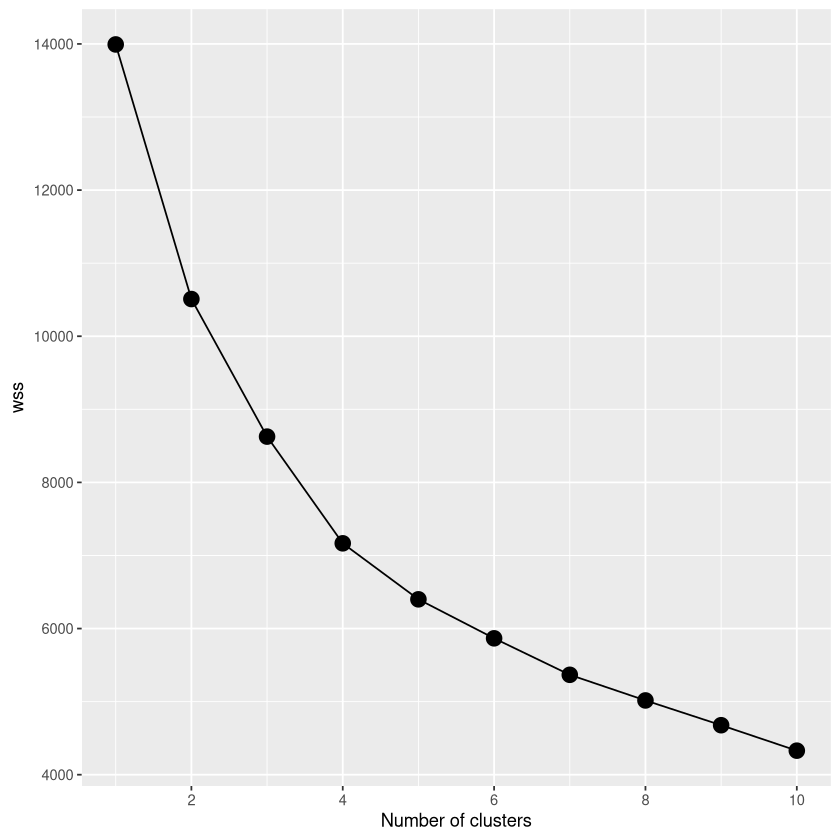

In [ ]:
n_clusters <- 10

wss <- numeric(n_clusters)

set.seed(123)

for (i in 1:n_clusters) {
  km.out <- kmeans(dataset_final, centers = i, nstart = 20)
  wss[i] <- km.out$tot.withinss
}

wss_df <- tibble(clusters = 1:n_clusters, wss = wss)

scree_plot <- ggplot(wss_df, aes(x = clusters, y = wss, group = 1)) +
    geom_point(size = 4)+
    geom_line() +
    scale_x_continuous(breaks = c(2, 4, 6, 8, 10)) +
    xlab('Number of clusters')
scree_plot


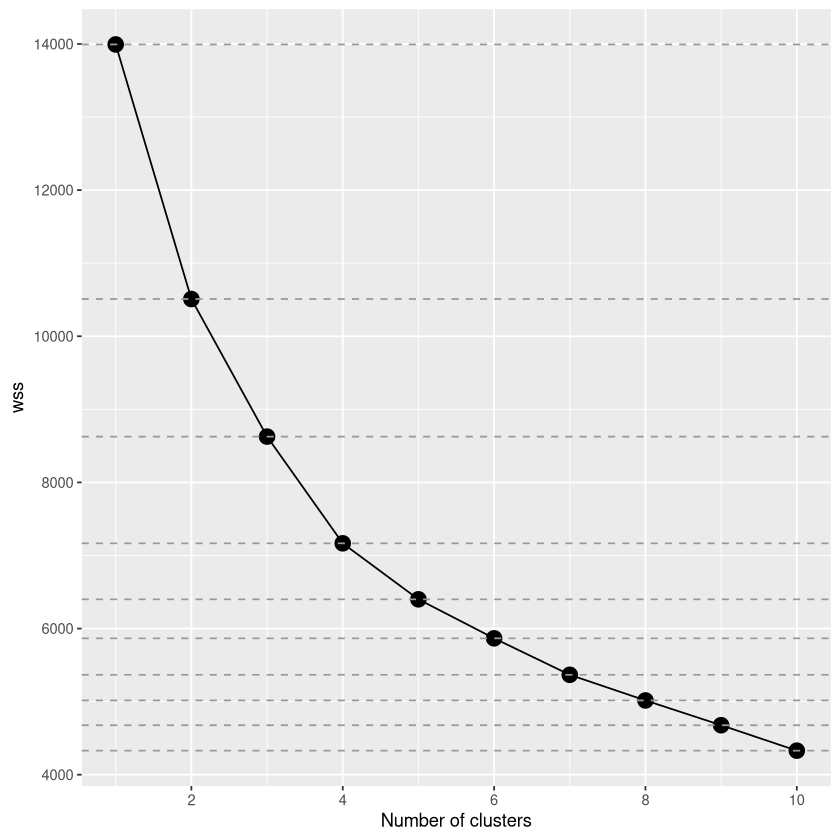

In [ ]:
scree_plot +
  geom_hline(
    yintercept = wss,
    linetype = 'dashed',
    color = 'gray60',
    linewidth = 0.5
  )

In [ ]:
km.out <- kmeans(dataset_final, centers = 4, nstart = 20)
print(km.out)

K-means clustering with 4 clusters of sizes 462, 570, 705, 263

Cluster means:
          Sex Marital.status         Age   Education     Income Occupation
1 -0.20909486     -0.9538238 -0.02825041 -0.48558943 -0.6060162 -0.7540014
2 -0.85731349     -0.6454860 -0.02337255 -0.50796416  0.5317359  0.7225792
3  0.79655407      1.0011004 -0.59268205  0.05016025 -0.3987344 -0.2763247
4  0.09011369      0.3909422  1.68902999  1.81946354  0.9809802  0.4991919
  Settlement.size
1      -0.8562241
2       0.9646469
3      -0.3892828
4       0.4569247

Clustering vector:
   [1] 4 3 1 2 2 1 2 2 4 2 3 3 3 1 3 3 1 2 4 2 2 2 1 2 2 1 1 4 2 4 2 2 2 1 3 1 2
  [38] 2 2 2 2 3 1 2 4 3 1 3 1 3 1 2 2 1 4 1 2 3 3 3 2 2 4 2 3 2 3 3 2 3 3 1 2 3
  [75] 2 4 2 2 1 3 4 2 3 4 1 3 3 2 2 2 2 2 3 2 2 4 4 2 2 2 1 1 3 2 3 2 2 2 3 3 2
 [112] 3 2 3 2 2 3 3 3 2 3 4 1 4 3 2 1 2 2 3 3 2 1 2 3 3 2 4 2 3 3 3 2 2 3 2 3 4
 [149] 2 2 1 2 2 2 2 3 2 3 2 1 2 3 2 4 2 2 3 3 3 2 1 3 2 1 2 4 4 2 2 4 2 2 1 2 2
 [186] 2 4 1 3 3 2 1 2 3 2 2 3 

-----------------------------------------------
#Seção 5: Resultados e Interpretação
-----------------------------------------------
● 5.1. Apresentação dos Resultados: Mostre a saída do seu modelo de forma clara.
Pode ser uma tabela com coeficientes, uma visualização dos clusters, uma imagem da
árvore de decisão, etc.

● 5.2. Análise Crítica dos Resultados: Esta é a parte mais importante. Traduza a
saída técnica em uma explicação clara e objetiva.
  
○ Exemplo para K-Means: "O modelo identificou 3 clusters. O Cluster 1, que
chamamos de 'Clientes Econômicos', é caracterizado por... O Cluster 2,
'Clientes Premium', por sua vez..."
  
○ Exemplo para Regressão Linear: "O coeficiente para a variável 'área_m2' foi
de 850. Isso sugere que, mantendo as outras variáveis constantes, cada metro
quadrado adicional está associado a um aumento de R$850 no preço do
aluguel."

-----------------------------------------------
#Seção 6: Conclusão
-----------------------------------------------
● 6.1. Resumo dos Insights: Sintetize as principais descobertas do seu projeto.
Responda diretamente à pergunta que você se propôs a investigar na introdução.

● 6.2. Recomendações Práticas: Com base nos seus achados, o que você recomendaria
para uma empresa ou área de estudo? Proponha 1 ou 2 ações concretas.

● 6.3. Limitações e Próximos Passos: Nenhum projeto é perfeito. Discuta as limitações
da sua análise (ex: poucos dados, variáveis faltantes, simplicidade do modelo).

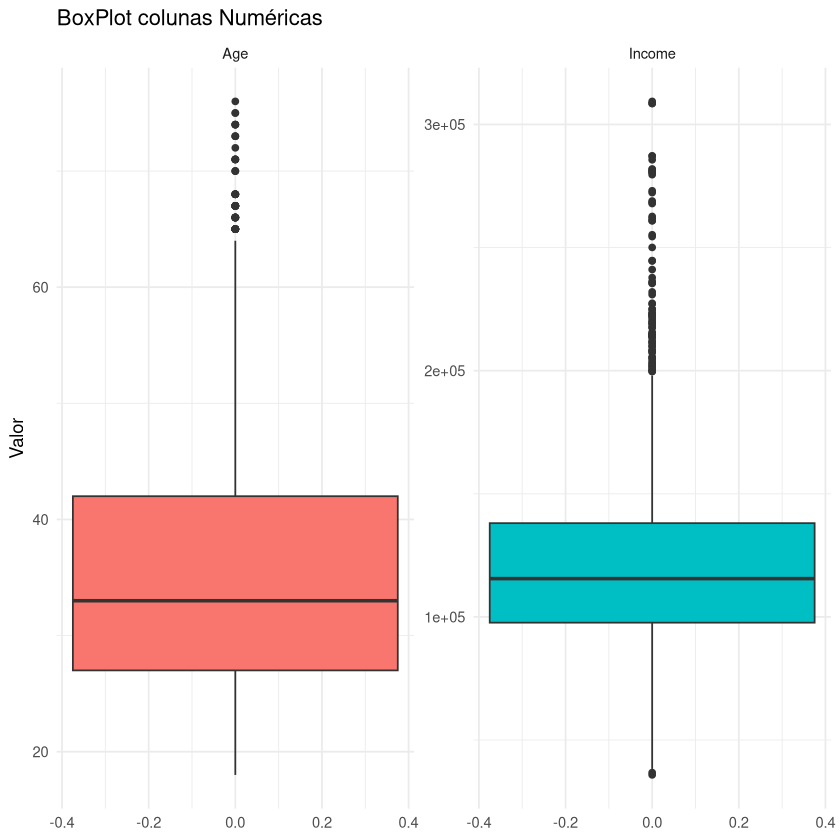

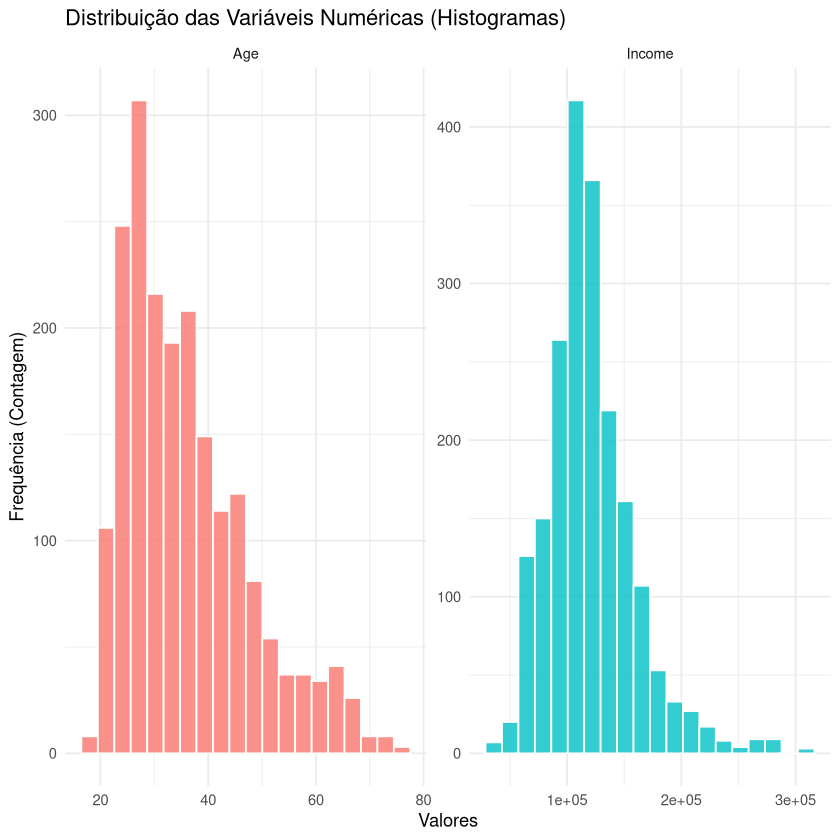

In [ ]:
dados_longo <- dataset_sem_id %>%
  select(where(is.numeric)) %>%
  pivot_longer(cols = everything(), names_to = "Variavel", values_to = "Valor")

ggplot(dados_longo, aes(y = Valor, fill = Variavel)) +
  geom_boxplot() +
  facet_wrap(~Variavel, scales = "free") +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(title = "BoxPlot colunas Numéricas")

dados_longo <- dataset_sem_id %>%
  select(where(is.numeric)) %>%
  pivot_longer(cols = everything(), names_to = "Variavel", values_to = "Valor")

ggplot(dados_longo, aes(x = Valor, fill = Variavel)) +
  geom_histogram(bins = 20, color = "white", alpha = 0.8) +
  facet_wrap(~Variavel, scales = "free") +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(
    title = "Distribuição das Variáveis Numéricas (Histogramas)",
    x = "Valores",
    y = "Frequência (Contagem)"
  )